In [2]:
import matplotlib.pyplot as plt
import numpy as np

import nn
import load_mnist
from train import train

In [2]:
network = nn.Sequential([
    nn.Linear(28 * 28, 100),
    nn.Sigmoid(100),
    nn.Linear(100, 10),
    nn.Softmax(10, True),
])

training_inputs = load_mnist.load_data("mnist_data/train-images.idx3-ubyte")
training_inputs = training_inputs / np.max(training_inputs)
training_labels = load_mnist.load_labels("mnist_data/train-labels.idx1-ubyte")
training_targets = load_mnist.one_hot(training_labels)

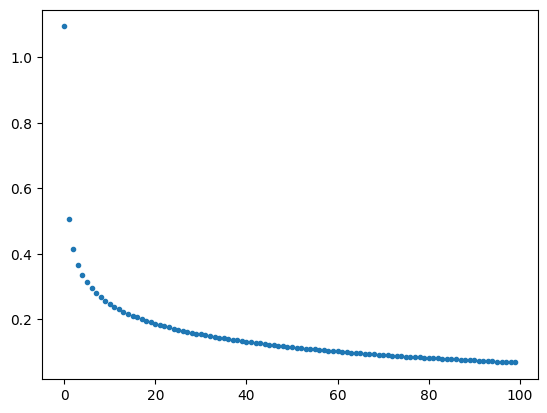

In [3]:
network.load("testnet.npz")

#epoch, loss = train(network, nn.CrossEntropyLoss(True), training_inputs, training_targets, N_epoch=100)
#network.save("testnet.npz")

epoch = np.load("epoch.npy")
loss = np.load("loss.npy")
plt.plot(epoch, loss, ".")
plt.show()

In [4]:
# np.save("epoch.npy", epoch)
# np.save("loss.npy", loss)

In [5]:
test_inputs = load_mnist.load_data("mnist_data/t10k-images.idx3-ubyte")
test_inputs = test_inputs / np.max(test_inputs)
test_labels = load_mnist.load_labels("mnist_data/t10k-labels.idx1-ubyte")
test_targets = load_mnist.one_hot(test_labels)

In [6]:
test_inputs.shape

(10000, 28, 28)

In [9]:
def test(net, test_inputs, test_targets):
    correct = 0
    test_inputs = np.reshape(test_inputs, (test_inputs.shape[0], np.prod(test_inputs.shape[1:])))
    print(test_inputs.shape)
    for x, target in zip(test_inputs, test_targets):
        prediction = net.forward(x)
        if np.argmax(prediction) == np.argmax(target):
            correct += 1
    print("Correct:", correct, "Count:", len(test_inputs), "Accuracy:", correct / len(test_inputs))

In [10]:
test(network, test_inputs, test_targets)

(10000, 784)
Correct: 9649 Count: 10000 Accuracy: 0.9649


In [3]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

In [6]:
a + b[:, np.newaxis]

array([[5, 6, 7],
       [6, 7, 8],
       [7, 8, 9]])

In [6]:
np.stack((a, b), axis=1)

array([[1, 4],
       [2, 5],
       [3, 6]])